In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, recall_score, roc_auc_score, cohen_kappa_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

### Load data

In [2]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


### Train-test split

In [3]:
X = df.drop(columns=['status'])
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [4]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2413})
After SMOTE:  Counter({0: 2828, 1: 2828})


# Decision Tree

## Simple mode

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)


DecisionTreeClassifier(random_state=42)

In [6]:
y_pred = dt.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.718     0.693     0.706       707
           1      0.655     0.682     0.668       604

    accuracy                          0.688      1311
   macro avg      0.687     0.688     0.687      1311
weighted avg      0.689     0.688     0.688      1311



### Average Precision Score

In [7]:
y_probas = dt.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.5948096348434722


## Hyperparameter Tuning

In [8]:
params = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 12],
    'min_samples_leaf': [2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    scoring='recall',        
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)


Fitting 10 folds for each of 64 candidates, totalling 640 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [2, 4],
                         'min_samples_split': [2, 5, 10, 12]},
             scoring='recall', verbose=1)

In [9]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best cross-validation recall score: {grid_search.best_score_:.3f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 12}
Best cross-validation recall score: 0.743


In [10]:
dt_tune = grid_search.best_estimator_
y_pred_tune = dt_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_tune, digits=3))

Classification Report:
               precision    recall  f1-score   support

           0      0.766     0.629     0.691       707
           1      0.641     0.775     0.702       604

    accuracy                          0.696      1311
   macro avg      0.704     0.702     0.696      1311
weighted avg      0.708     0.696     0.696      1311



### Average precision

In [11]:
y_probas_tune = dt_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.7224905715954646


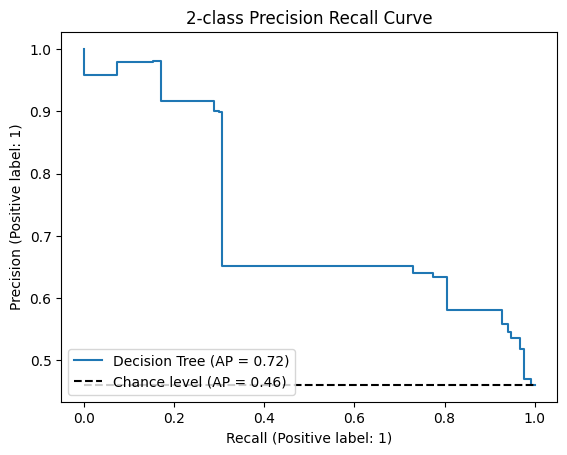

In [12]:
display = PrecisionRecallDisplay.from_estimator(
    dt_tune,
    X_test,
    y_test, 
    name="Decision Tree",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Recall score on train set

In [13]:
# Recall on base model
y_train_pred = dt.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tune tune model
y_train_pred = dt_tune.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Tune Model): {train_recall:.3f}")

Recall on Training set (Base Model): 0.986
Recall on Training set (Tune Model): 0.755


### AUC score

In [25]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.689
AUC: 0.780


### Cohen's Kappa

In [24]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa: {kappa_tune:.3f}")

Cohen's Kappa: 0.374
Cohen's Kappa: 0.398


### Confusion matrix

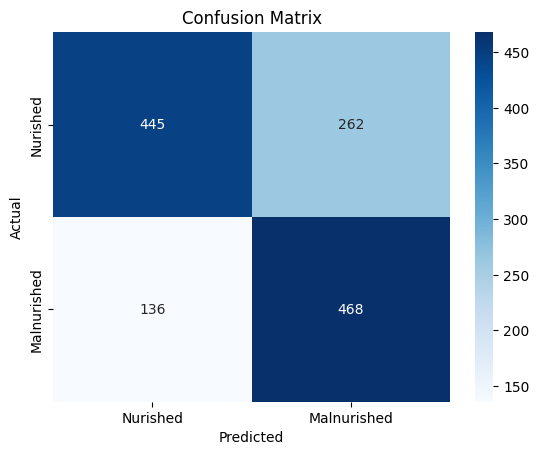

In [16]:
cm = confusion_matrix(y_test, y_pred_tune)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature importance

In [17]:
# Get feature importances in simple model
feature_importance = dt.feature_importances_
feature_names = X_train_sm.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                            Feature  Importance
1                      child_weight    0.382165
0                         child_age    0.150396
8                      wealth_index    0.108180
6                  mother_education    0.071893
4                              area    0.039862
3                fever_last_2_weeks    0.037654
5                         child_sex    0.034209
9         province_Gandaki Province    0.030411
12              province_Province 2    0.027745
11              province_Province 1    0.024825
13              province_Province 5    0.023864
14  province_Sudoorpaschim Province    0.021055
10        province_Karnali Province    0.020193
2            diarrhoea_last_2_weeks    0.017086
7                  health_insurance    0.010463


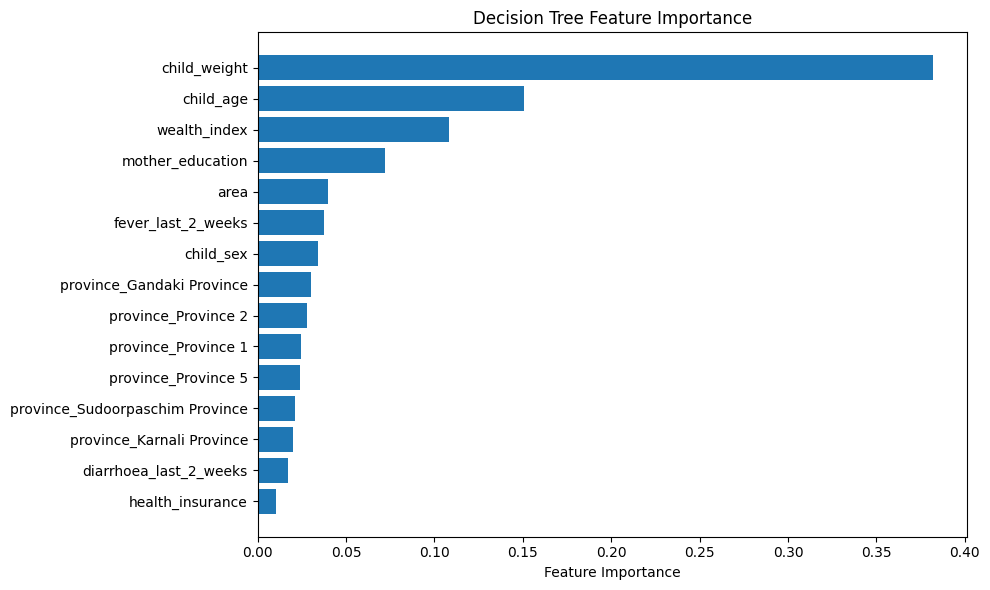

In [18]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
# Get feature importances in tuned model
feature_importance = dt_tune.feature_importances_
feature_names = X_train_sm.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                            Feature  Importance
1                      child_weight    0.520010
0                         child_age    0.431583
8                      wealth_index    0.015970
6                  mother_education    0.012610
10        province_Karnali Province    0.007342
9         province_Gandaki Province    0.005813
12              province_Province 2    0.003436
4                              area    0.002090
3                fever_last_2_weeks    0.001147
2            diarrhoea_last_2_weeks    0.000000
5                         child_sex    0.000000
7                  health_insurance    0.000000
11              province_Province 1    0.000000
13              province_Province 5    0.000000
14  province_Sudoorpaschim Province    0.000000


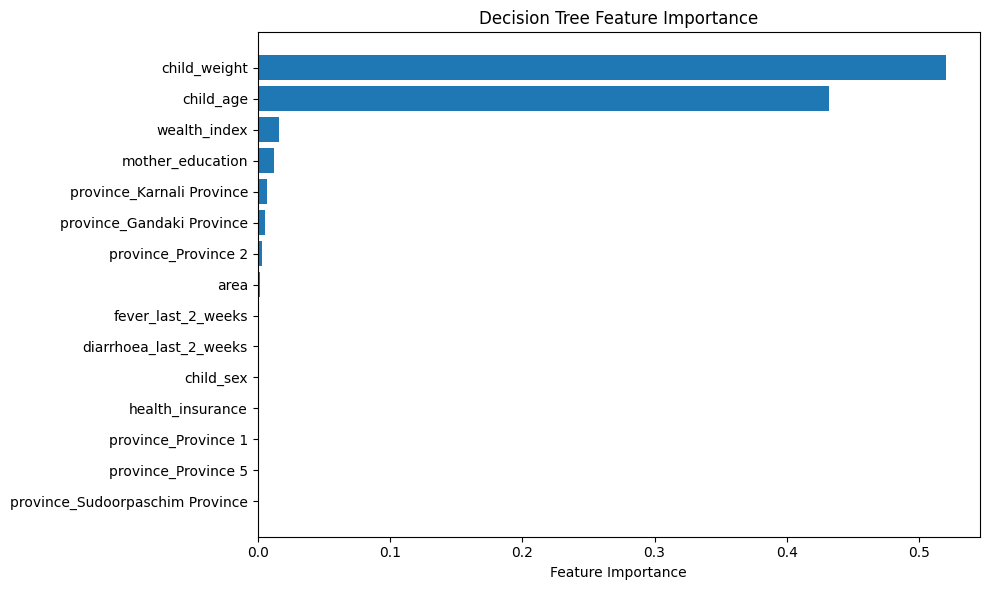

In [20]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


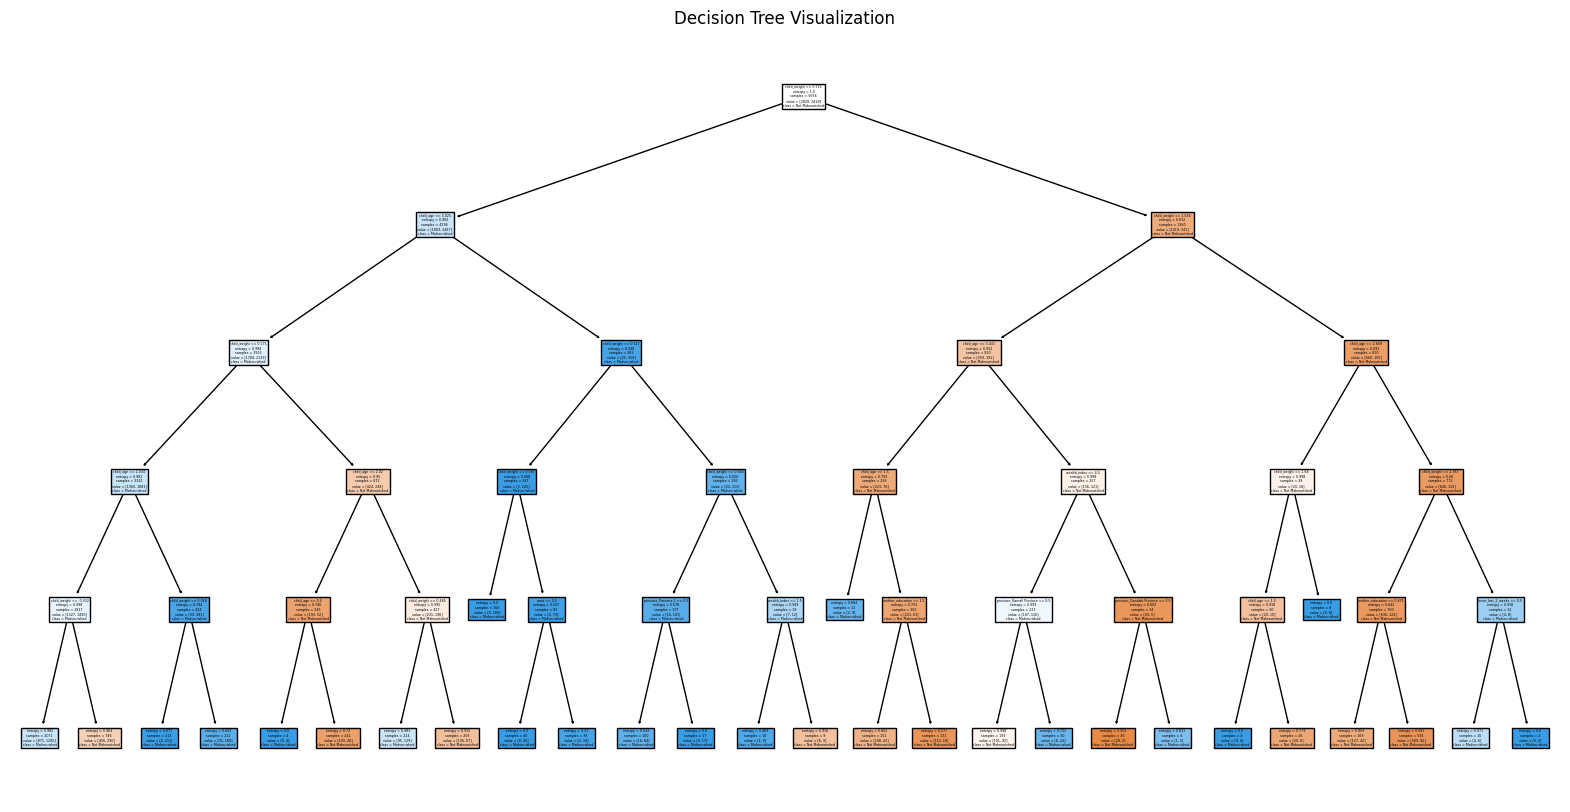

In [21]:
plt.figure(figsize=(20, 10))
plot_tree(dt_tune, feature_names=X.columns, class_names=['Not Malnourished', 'Malnourished'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

## Additional

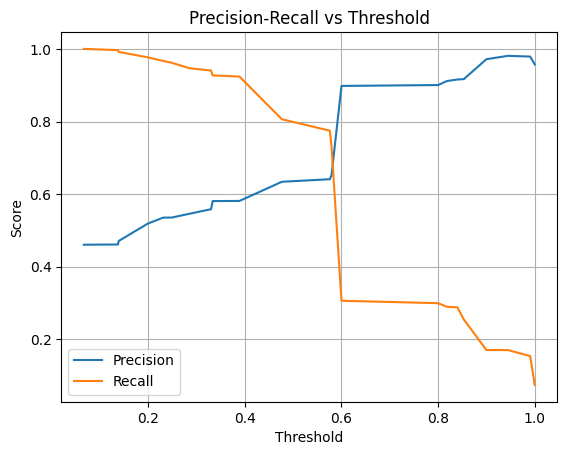

In [22]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probas_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [23]:
# Apply custom threshold
y_probas_custom = (y_probas_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.60      0.68       707
           1       0.63      0.81      0.71       604

    accuracy                           0.70      1311
   macro avg       0.71      0.70      0.70      1311
weighted avg       0.72      0.70      0.69      1311


